In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_ind
import pingouin as pg
from statsmodels.multivariate.manova import MANOVA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Survey Results/results-survey-final-cleaned2.csv", delimiter=";")
df.rename(columns={df.columns[13]: 'group_number'}, inplace=True)

In [4]:
mapping = {
    1: ('left', 'low', 'human'),
    2: ('left', 'low', 'LLM'),
    3: ('left', 'low', 'control'),
    4: ('left', 'medium', 'human'),
    5: ('left', 'medium', 'LLM'),
    6: ('left', 'medium', 'control'),
    7: ('left', 'high', 'human'),
    8: ('left', 'high', 'LLM'),
    9: ('left', 'high', 'control'),

    10: ('center', 'low', 'human'),
    11: ('center', 'low', 'LLM'),
    12: ('center', 'low', 'control'),
    13: ('center', 'medium', 'human'),
    14: ('center', 'medium', 'LLM'),
    15: ('center', 'medium', 'control'),
    16: ('center', 'high', 'human'),
    17: ('center', 'high', 'LLM'),
    18: ('center', 'high', 'control'),

    19: ('right', 'low', 'human'),
    20: ('right', 'low', 'LLM'),
    21: ('right', 'low', 'control'),
    22: ('right', 'medium', 'human'),
    23: ('right', 'medium', 'LLM'),
    24: ('right', 'medium', 'control'),
    25: ('right', 'high', 'human'),
    26: ('right', 'high', 'LLM'),
    27: ('right', 'high', 'control'),
    
}

# Apply the mapping to create new columns
df[['article_orientation', 'article_bias_level', 'explanation_type']] = df['group_number'].map(mapping).apply(pd.Series)

In [5]:
df = df.rename(columns={
    "After reading the short text after the article, please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t2",
    "Please tell us what you think about the following sentence: In my opinion, this article is biased.": "bias_t1",
    "Do you consider yourself to be liberal, conservative or somewhere in between?   [Political Orientation|Liberal|Conservative]": "Participant_Political_Lean",
    "The explanation was useful. [agree|disagree]": "Usefulness",
    "The explanation was complete. [agree|disagree]": "Completeness"
})

In [6]:
# UEQ Score
# Step 1: Reverse-code the negatively-keyed items
df["valuable_rc"] = -1 * df["The explanation was… [valuable|inferior]"]
df["good_rc"] = -1 * df["The explanation was… [good|bad]"]
df["clear_rc"] = -1 * df["The explanation was… [clear|confusing]"]

# Step 2: List of correctly-coded items (original or reversed)
ueq_items = [
    "The explanation was… [not understandable|understandable]",
    "valuable_rc",
    "The explanation was… [obstructive|supportive]",
    "good_rc",
    "The explanation was… [complicated|easy]",
    "clear_rc"
]

# Step 3: Compute the mean UEQ score per participant
df["UEQ"] = df[ueq_items].mean(axis=1)


In [7]:
relevant_columns = [
    'article_orientation', 
    'article_bias_level',             
    'explanation_type',    
    'bias_t1',
    'bias_t2',
    'Participant_Political_Lean',
    'Usefulness',
    'Completeness', 
    'UEQ'
]

df_relevant = df[relevant_columns].copy()

In [8]:
# Remove any zero-width spaces (or other invisible characters)
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.replace(r'\u200b', '', regex=True)
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.replace(r'\u200b', '', regex=True)

# Now you can safely strip any remaining whitespace and map the values
df_relevant['bias_t1'] = df_relevant['bias_t1'].str.strip()
df_relevant['bias_t2'] = df_relevant['bias_t2'].str.strip()
bias_scale = {
    "Strongly disagree": -3,
    "Disagree": -2,
    "Somewhat disagree": -1,
    "Somewhat agree": 1,
    "Agree": 2,
    "Strongly agree": 3
}

# Map responses in bias_t1 and bias_t2 to numeric values
df_relevant['bias_t1_num'] = df_relevant['bias_t1'].map(bias_scale)
df_relevant['bias_t2_num'] = df_relevant['bias_t2'].map(bias_scale)

# Calculate the change in perceived bias
df_relevant['BiasChange'] = df_relevant['bias_t2_num'] - df_relevant['bias_t1_num']

Mean bias change: 0.3499005964214712
Median bias change: 0.0
Standard deviation: 1.6462062477161103
Count of positive changes: 176
Count of negative changes: 94
Count of zero changes: 233


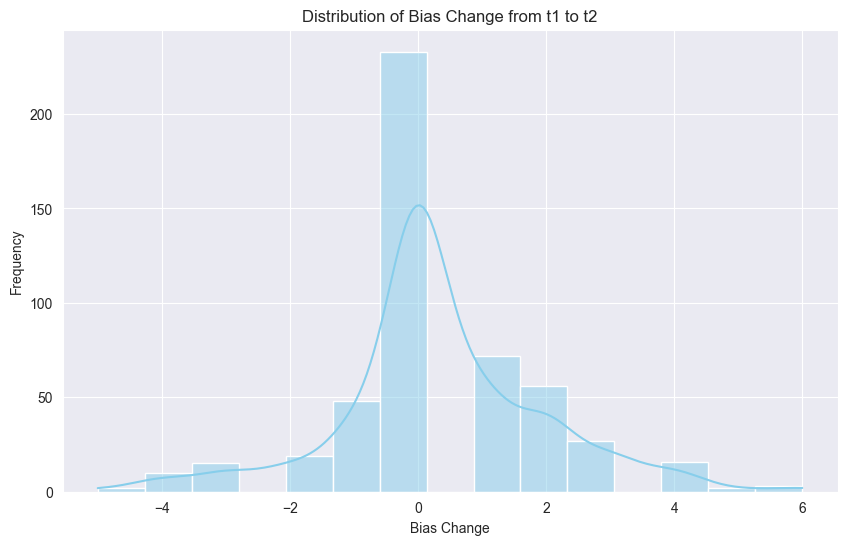

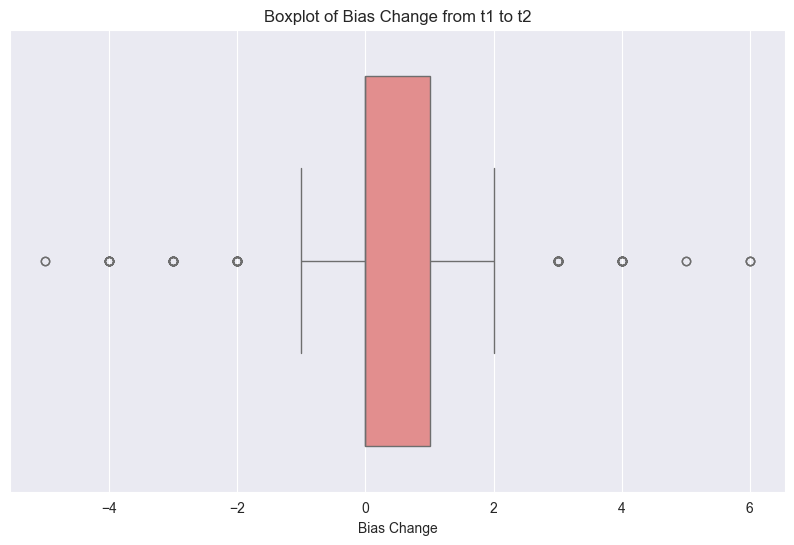

In [9]:
#General bias change analysis
mean_bias_change = df_relevant['BiasChange'].mean()
median_bias_change = df_relevant['BiasChange'].median()
std_bias_change = df_relevant['BiasChange'].std()
count_positive = len(df_relevant[df_relevant['BiasChange'] > 0])
count_negative = len(df_relevant[df_relevant['BiasChange'] < 0])
count_zero = len(df_relevant[df_relevant['BiasChange'] == 0])

print(f"Mean bias change: {mean_bias_change}")
print(f"Median bias change: {median_bias_change}")
print(f"Standard deviation: {std_bias_change}")
print(f"Count of positive changes: {count_positive}")
print(f"Count of negative changes: {count_negative}")
print(f"Count of zero changes: {count_zero}")

# 2. Visualization
plt.figure(figsize=(10, 6))

# Histogram of bias change
sns.histplot(df_relevant['BiasChange'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Bias Change from t1 to t2')
plt.xlabel('Bias Change')
plt.ylabel('Frequency')

plt.show()

# Boxplot for visualizing the spread
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_relevant['BiasChange'], color='lightcoral')
plt.title('Boxplot of Bias Change from t1 to t2')
plt.xlabel('Bias Change')

plt.show()

In [10]:
df['explanation_type'] = df['explanation_type'].astype('category')
df['article_bias_level'] = df['article_bias_level'].astype('category')

In [11]:
print(df_relevant['explanation_type'].unique())
print(df_relevant['article_bias_level'].unique())

['LLM' 'human' 'control']
['high' 'low' 'medium']


HYPOTHESIS TESTING 1&2

HYPOTHESIS 1: Explanations vs Control
--------------------------------------------------
Explanation group mean: 1.177 (n=333)
Control group mean: 0.859 (n=170)
Difference: 0.318
t-statistic: 2.616
One-tailed p-value (Explanations > Control): 0.004585
Effect size (Cohen's d): 0.247

Detailed breakdown:
  human vs Control: t = 1.529, p = 0.063637
  LLM vs Control: t = 3.033, p = 0.001303


HYPOTHESIS 1.1: Medium bias > Low bias AND Medium bias > High bias
------------------------------------------------------------
Overall ANOVA for bias levels:
                           sum_sq     df         F    PR(>F)
C(article_bias_level)    5.253453    2.0  1.561091  0.210928
Residual               841.311159  500.0       NaN       NaN

Means by bias level:
                        mean       std  count
article_bias_level                           
high                0.954023  1.293899    174
low                 1.203704  1.314699    162
medium              1.059880  1.2833

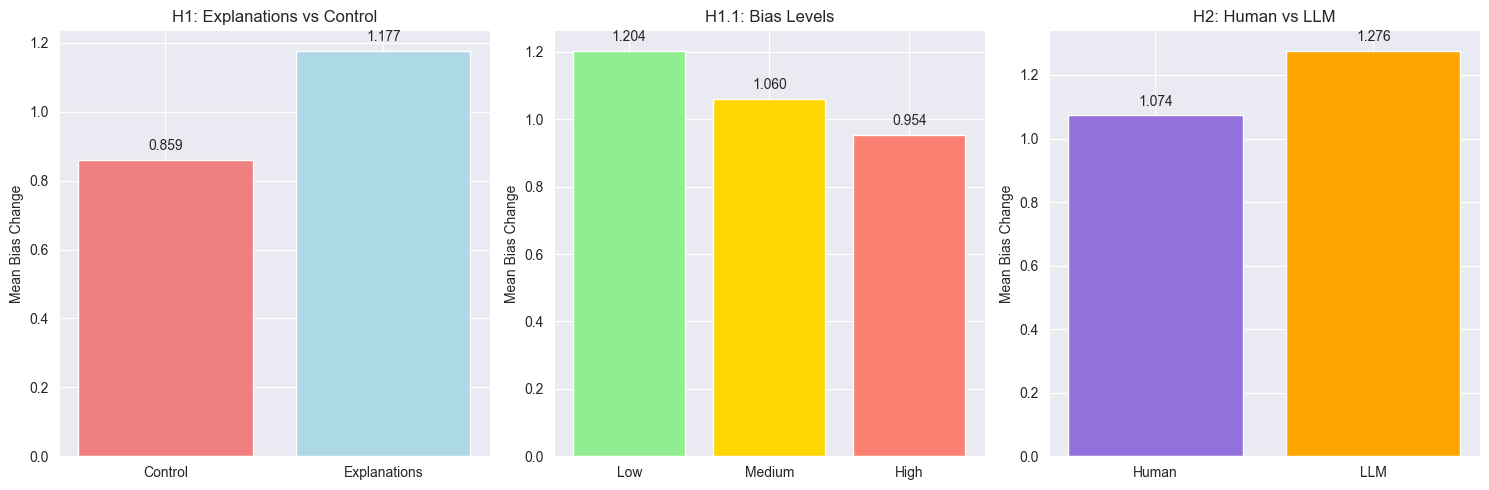

Effect size (Cohen's d): 0.247
  human vs Control: t = 1.529, p = 0.063637, Cohen's d = 0.168
  LLM vs Control: t = 3.033, p = 0.001303, Cohen's d = 0.329
Effect size (Cohen's d): -0.154
  Low bias: t=-1.526, p=0.9350, Cohen's d=-0.291
  Medium bias: t=0.057, p=0.4771, Cohen's d=0.011
  High bias: t=-0.975, p=0.8342, Cohen's d=-0.185


In [26]:
def cohens_d(x, y):
    """
    Compute Cohen's d for independent samples.
    """
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
    d = (x.mean() - y.mean()) / pooled_std
    return d

print("="*80)
print("HYPOTHESIS TESTING 1&2")
print("="*80)
# Create absolute bias change variable
df_relevant['BiasChange_Abs'] = np.abs(df_relevant['BiasChange'])
# ============================================================================
# HYPOTHESIS 1: Explanations vs Control
# ============================================================================
print("\nHYPOTHESIS 1: Explanations vs Control")
print("-" * 50)

# Create a combined explanation group vs control
df_relevant['explanation_group'] = df_relevant['explanation_type'].apply(
    lambda x: 'Explanation' if x in ['human', 'LLM'] else 'Control'
)

# Test H1: Explanations > Control
explanation_data = df_relevant[df_relevant['explanation_group'] == 'Explanation']['BiasChange_Abs']
control_data = df_relevant[df_relevant['explanation_group'] == 'Control']['BiasChange_Abs']

# Independent samples t-test (one-tailed)
t_stat, p_val_two_tailed = ttest_ind(explanation_data, control_data)
p_val_one_tailed = p_val_two_tailed / 2 if t_stat > 0 else 1 - (p_val_two_tailed / 2)

print(f"Explanation group mean: {explanation_data.mean():.3f} (n={len(explanation_data)})")
print(f"Control group mean: {control_data.mean():.3f} (n={len(control_data)})")
print(f"Difference: {explanation_data.mean() - control_data.mean():.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"One-tailed p-value (Explanations > Control): {p_val_one_tailed:.6f}")
print(f"Effect size (Cohen's d): {(explanation_data.mean() - control_data.mean()) / np.sqrt(((len(explanation_data)-1)*explanation_data.var() + (len(control_data)-1)*control_data.var()) / (len(explanation_data) + len(control_data) - 2)):.3f}")

# Also test each explanation type vs control separately
print(f"\nDetailed breakdown:")
for exp_type in ['human', 'LLM']:
    exp_data = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange_Abs']
    t_stat_ind, p_val_ind = (ttest_ind(exp_data, control_data))
    p_val_one_tailed_ind = p_val_ind / 2 if t_stat_ind > 0 else 1 - (p_val_ind / 2)
    print(f"  {exp_type} vs Control: t = {t_stat_ind:.3f}, p = {p_val_one_tailed_ind:.6f}")

# ============================================================================
# HYPOTHESIS 1.1: Medium bias > (Low bias OR High bias)
# ============================================================================
print(f"\n\nHYPOTHESIS 1.1: Medium bias > Low bias AND Medium bias > High bias")
print("-" * 60)

# First, run the overall ANOVA
model_bias = smf.ols('BiasChange_Abs ~ C(article_bias_level)', data=df_relevant).fit()
anova_bias = sm.stats.anova_lm(model_bias, typ=2)
print("Overall ANOVA for bias levels:")
print(anova_bias)

# Get means for each bias level
bias_means = df_relevant.groupby('article_bias_level')['BiasChange_Abs'].agg(['mean', 'std', 'count'])
print(f"\nMeans by bias level:")
print(bias_means)

# Specific contrasts for H1.1
medium_data = df_relevant[df_relevant['article_bias_level'] == 'medium']['BiasChange_Abs']
low_data = df_relevant[df_relevant['article_bias_level'] == 'low']['BiasChange_Abs']
high_data = df_relevant[df_relevant['article_bias_level'] == 'high']['BiasChange_Abs']

# Test: Medium > Low (one-tailed)
t_med_low, p_med_low = ttest_ind(medium_data, low_data)
p_med_low_one = p_med_low / 2 if t_med_low > 0 else 1 - (p_med_low / 2)

# Test: Medium > High (one-tailed)
t_med_high, p_med_high = ttest_ind(medium_data, high_data)
p_med_high_one = p_med_high / 2 if t_med_high > 0 else 1 - (p_med_high / 2)

print(f"\nDirectional tests:")
print(f"Medium vs Low: t = {t_med_low:.3f}, p (one-tailed) = {p_med_low_one:.6f}")
print(f"Medium vs High: t = {t_med_high:.3f}, p (one-tailed) = {p_med_high_one:.6f}")

# Bonferroni correction for multiple comparisons
alpha_corrected = 0.05 / 2  # Two comparisons
print(f"\nWith Bonferroni correction (α = {alpha_corrected}):")
print(f"Medium > Low: {'Significant' if p_med_low_one < alpha_corrected else 'Not significant'}")
print(f"Medium > High: {'Significant' if p_med_high_one < alpha_corrected else 'Not significant'}")

# ============================================================================
# HYPOTHESIS 2: Human > LLM
# ============================================================================
print(f"\n\nHYPOTHESIS 2: Human > LLM explanations")
print("-" * 45)

# Filter to only explanation conditions
df_explanations = df_relevant[df_relevant['explanation_type'].isin(['human', 'LLM'])]

# Overall comparison
human_data = df_explanations[df_explanations['explanation_type'] == 'human']['BiasChange_Abs']
llm_data = df_explanations[df_explanations['explanation_type'] == 'LLM']['BiasChange_Abs']

t_human_llm, p_human_llm = ttest_ind(human_data, llm_data)
p_human_llm_one = p_human_llm / 2 if t_human_llm > 0 else 1 - (p_human_llm / 2)

print(f"Human mean: {human_data.mean():.3f} (n={len(human_data)})")
print(f"LLM mean: {llm_data.mean():.3f} (n={len(llm_data)})")
print(f"Difference (Human - LLM): {human_data.mean() - llm_data.mean():.3f}")
print(f"t-statistic: {t_human_llm:.3f}")
print(f"One-tailed p-value (Human > LLM): {p_human_llm_one:.6f}")

# Test within each bias level to see if pattern holds
print(f"\nBreakdown by bias level:")
for bias_level in ['low', 'medium', 'high']:
    subset = df_explanations[df_explanations['article_bias_level'] == bias_level]
    if len(subset) > 0:
        human_subset = subset[subset['explanation_type'] == 'human']['BiasChange_Abs']
        llm_subset = subset[subset['explanation_type'] == 'LLM']['BiasChange_Abs']

        if len(human_subset) > 0 and len(llm_subset) > 0:
            t_sub, p_sub = ttest_ind(human_subset, llm_subset)
            p_sub_one = p_sub / 2 if t_sub > 0 else 1 - (p_sub / 2)
            print(f"  {bias_level.capitalize()} bias: Human={human_subset.mean():.3f}, LLM={llm_subset.mean():.3f}, "
                  f"t={t_sub:.3f}, p={p_sub_one:.4f}")

# ============================================================================
# COMPREHENSIVE INTERACTION ANALYSIS
# ============================================================================
print(f"\n\nCOMPREHENSIVE INTERACTION ANALYSIS")
print("-" * 50)

# Full factorial ANOVA (your original analysis)
model_full = smf.ols('BiasChange_Abs ~ C(explanation_type) * C(article_bias_level)', data=df_relevant).fit()
anova_full = sm.stats.anova_lm(model_full, typ=2)
print("Full factorial ANOVA:")
print(anova_full)

# Effect sizes (eta-squared)
ss_total = anova_full['sum_sq'].sum()
print(f"\nEffect sizes (η²):")
for index, row in anova_full.iterrows():
    if 'Residual' not in index:
        eta_squared = row['sum_sq'] / ss_total
        print(f"  {index}: η² = {eta_squared:.3f}")

# ============================================================================
# SUMMARY AND INTERPRETATION
# ============================================================================
print(f"\n\n" + "="*80)
print("HYPOTHESIS TESTING SUMMARY")
print("="*80)

print(f"\nH1: Explanations > Control")
print(f"   Result: {'SUPPORTED' if p_val_one_tailed < 0.05 else 'NOT SUPPORTED'} (p = {p_val_one_tailed:.4f})")

print(f"\nH1.1: Medium bias > Low bias AND Medium bias > High bias")
both_significant = (p_med_low_one < alpha_corrected) and (p_med_high_one < alpha_corrected)
print(f"   Result: {'SUPPORTED' if both_significant else 'NOT SUPPORTED'}")
print(f"   - Medium > Low: {'Yes' if p_med_low_one < alpha_corrected else 'No'} (p = {p_med_low_one:.4f})")
print(f"   - Medium > High: {'Yes' if p_med_high_one < alpha_corrected else 'No'} (p = {p_med_high_one:.4f})")

print(f"\nH2: Human > LLM")
print(f"   Result: {'SUPPORTED' if p_human_llm_one < 0.05 else 'NOT SUPPORTED'} (p = {p_human_llm_one:.4f})")

print(f"\nInteraction Effect (explanation_type × article_bias_level):")
interaction_p = anova_full.loc['C(explanation_type):C(article_bias_level)', 'PR(>F)']
print(f"   {'Significant' if interaction_p < 0.05 else 'Not significant'} interaction (p = {interaction_p:.4f})")

print("\n" + "="*80)

# Optional: Create a summary plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# H1: Explanations vs Control
groups = ['Control', 'Explanations']
means = [control_data.mean(), explanation_data.mean()]
ax1.bar(groups, means, color=['lightcoral', 'lightblue'])
ax1.set_ylabel('Mean Bias Change')
ax1.set_title('H1: Explanations vs Control')
for i, v in enumerate(means):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# H1.1: Bias levels
bias_levels = ['Low', 'Medium', 'High']
bias_level_means = [low_data.mean(), medium_data.mean(), high_data.mean()]
bars = ax2.bar(bias_levels, bias_level_means, color=['lightgreen', 'gold', 'salmon'])
ax2.set_ylabel('Mean Bias Change')
ax2.set_title('H1.1: Bias Levels')
for i, v in enumerate(bias_level_means):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# H1.2: Human vs LLM
exp_types = ['Human', 'LLM']
exp_means = [human_data.mean(), llm_data.mean()]
ax3.bar(exp_types, exp_means, color=['mediumpurple', 'orange'])
ax3.set_ylabel('Mean Bias Change')
ax3.set_title('H2: Human vs LLM')
for i, v in enumerate(exp_means):
    ax3.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# H1: Explanations vs Control
d_h1 = cohens_d(explanation_data, control_data)
print(f"Effect size (Cohen's d): {d_h1:.3f}")

# H1 detailed breakdown
for exp_type in ['human', 'LLM']:
    exp_data = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange_Abs']
    t_stat_ind, p_val_ind = ttest_ind(exp_data, control_data)
    p_val_one_tailed_ind = p_val_ind / 2 if t_stat_ind > 0 else 1 - (p_val_ind / 2)
    d_ind = cohens_d(exp_data, control_data)
    print(f"  {exp_type} vs Control: t = {t_stat_ind:.3f}, p = {p_val_one_tailed_ind:.6f}, Cohen's d = {d_ind:.3f}")

# H2: Human vs LLM
d_h2 = cohens_d(human_data, llm_data)
print(f"Effect size (Cohen's d): {d_h2:.3f}")

# Optional: Bias-level breakdown
for bias_level in ['low', 'medium', 'high']:
    subset = df_explanations[df_explanations['article_bias_level'] == bias_level]
    human_subset = subset[subset['explanation_type'] == 'human']['BiasChange_Abs']
    llm_subset = subset[subset['explanation_type'] == 'LLM']['BiasChange_Abs']
    if len(human_subset) > 0 and len(llm_subset) > 0:
        t_sub, p_sub = ttest_ind(human_subset, llm_subset)
        p_sub_one = p_sub / 2 if t_sub > 0 else 1 - (p_sub / 2)
        d_sub = cohens_d(human_subset, llm_subset)
        print(f"  {bias_level.capitalize()} bias: t={t_sub:.3f}, p={p_sub_one:.4f}, Cohen's d={d_sub:.3f}")


In [18]:
df_llm_human = df_relevant.dropna(subset=['UEQ', 'Usefulness', 'Completeness', 'explanation_type'])

In [20]:
# H3: One-Way MANOVA (UEQ, Usefulness, Completeness)

manova = MANOVA.from_formula('UEQ + Usefulness + Completeness ~ C(explanation_type)', data=df_llm_human)
print(manova.mv_test())

# Follow-up ANOVAs
for dv in ['UEQ', 'Usefulness', 'Completeness']:
    model = smf.ols(f'{dv} ~ C(explanation_type)', data=df_llm_human).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    print(f"\nANOVA for {dv}")
    print(anova)

    # Tukey HSD
    tukey = pairwise_tukeyhsd(df_relevant[dv], df_relevant['explanation_type'])
    print(tukey)


                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.5841 3.0000 329.0000 78.0981 0.0000
         Pillai's trace 0.4159 3.0000 329.0000 78.0981 0.0000
 Hotelling-Lawley trace 0.7121 3.0000 329.0000 78.0981 0.0000
    Roy's greatest root 0.7121 3.0000 329.0000 78.0981 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
  C(explanation_type)   Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.9871 3.0000 329.0000  1.4277 0.2345
         Pillai's trace 0.0129 3.0000 329.0000  1.4277 0.2345
 Hotelling-Lawley trace 0.

In [21]:
print(df_llm_human['explanation_type'].value_counts())


explanation_type
LLM      170
human    163
Name: count, dtype: int64


In [22]:
# Make sure this is a full copy, not a view
df_llm_human = df_llm_human.copy()

# H4: Moderated Regression with Congruence
# Map article orientation to numeric direction
orientation_map = {'left': -1, 'center': 0, 'right': 1}
df_llm_human['orientation_numeric'] = df_llm_human['article_orientation'].map(orientation_map)

# Define congruence: congruent if orientation × lean > 0 or both zero
df_llm_human['congruent'] = np.sign(df_llm_human['orientation_numeric'] * df_llm_human['Participant_Political_Lean'])
df_llm_human['congruence'] = np.where(df_llm_human['congruent'] > 0, 'Congruent', 'Incongruent')
df_llm_human['congruence'] = df_llm_human['congruence'].astype('category')



In [23]:
# HYPOTHESIS 4
# Bias at T1 ~ political congruence
model_h4a = smf.ols('BiasChange_Abs ~ C(congruence)', data=df_llm_human).fit()
print(sm.stats.anova_lm(model_h4a, typ=2))

# ============================================================================
# HYPOTHESIS 4.1: BiasChange ~ explanation_type * congruence
# Expected: Greater increase when congruent vs incongruent
# ============================================================================
print("\n\nHYPOTHESIS 4: BiasChange_Abs ~ explanation_type × congruence")
print("-" * 50)

model_h1 = smf.ols('BiasChange_Abs ~ C(explanation_type) * C(congruence)', data=df_llm_human).fit()
print(sm.stats.anova_lm(model_h1, typ=2))
print("\nMeans by condition:")
print(df_llm_human.groupby(['explanation_type', 'congruence'])['BiasChange_Abs'].mean().unstack())

# Test simple effects for congruence within each explanation type
print("\nSimple effects of congruence within each explanation type:")
for exp_type in ['human', 'LLM']:
    subset = df_llm_human[df_llm_human['explanation_type'] == exp_type]
    model_simple = smf.ols('BiasChange_Abs ~ C(congruence)', data=subset).fit()
    print(f"\n{exp_type.upper()} explanations:")
    print(sm.stats.anova_lm(model_simple, typ=2))
    print(f"Means: {subset.groupby('congruence')['BiasChange_Abs'].mean()}")

# ============================================================================
# HYPOTHESIS 4.2: Human > LLM explanations when CONGRUENT
# ============================================================================
print("\n\nHYPOTHESIS 4.1: Human vs LLM explanations in CONGRUENT condition")
print("-" * 55)

# Filter to congruent condition only
df_congruent = df_llm_human[df_llm_human['congruence'] == 'Congruent']
model_h2 = smf.ols('BiasChange_Abs ~ C(explanation_type)', data=df_congruent).fit()
print(sm.stats.anova_lm(model_h2, typ=2))
print(f"Means in congruent condition: {df_congruent.groupby('explanation_type')['BiasChange_Abs'].mean()}")

# Also test in incongruent condition for comparison
print("\nFor comparison - Human vs LLM in INCONGRUENT condition:")
df_incongruent = df_llm_human[df_llm_human['congruence'] == 'Incongruent']
model_h2_inc = smf.ols('BiasChange_Abs ~ C(explanation_type)', data=df_incongruent).fit()
print(sm.stats.anova_lm(model_h2_inc, typ=2))
print(f"Means in incongruent condition: {df_incongruent.groupby('explanation_type')['BiasChange_Abs'].mean()}")

# ============================================================================
# HYPOTHESIS 4.3: UEQ, Completeness, Usefulness higher when INCONGRUENT
# ============================================================================
print("\n\nHYPOTHESIS 4.2: UEQ measures ~ explanation_type × congruence")
print("-" * 55)

for dv in ['UEQ', 'Usefulness', 'Completeness']:
    print(f"\n{dv.upper()} Analysis:")
    print("-" * 30)

    # Full interaction model
    model = smf.ols(f'{dv} ~ C(explanation_type) * C(congruence)', data=df_llm_human).fit()
    print("ANOVA Results:")
    print(sm.stats.anova_lm(model, typ=2))

    # Means by condition
    print(f"\nMeans by condition:")
    means_table = df_llm_human.groupby(['explanation_type', 'congruence'])[dv].mean().unstack()
    print(means_table)

    # Test main effect of congruence
    print(f"\nOverall means by congruence:")
    congruence_means = df_llm_human.groupby('congruence')[dv].mean()
    print(congruence_means)

    # Simple effect of congruence within each explanation type
    print(f"\nSimple effects of congruence:")
    for exp_type in ['human', 'LLM']:
        subset = df_llm_human[df_llm_human['explanation_type'] == exp_type]
        model_simple = smf.ols(f'{dv} ~ C(congruence)', data=subset).fit()
        p_value = sm.stats.anova_lm(model_simple, typ=2).iloc[0, 3]  # Get p-value
        means = subset.groupby('congruence')[dv].mean()
        print(f"  {exp_type.upper()}: p = {p_value:.4f}, Incongruent = {means.get('Incongruent', 'N/A'):.3f}, Congruent = {means.get('Congruent', 'N/A'):.3f}")


                   sum_sq     df         F    PR(>F)
C(congruence)    7.976522    1.0  4.627353  0.032189
Residual       570.570024  331.0       NaN       NaN


HYPOTHESIS 4: BiasChange_Abs ~ explanation_type × congruence
--------------------------------------------------
                                       sum_sq     df         F    PR(>F)
C(explanation_type)                  3.781220    1.0  2.214079  0.137714
C(congruence)                        8.333642    1.0  4.879733  0.027863
C(explanation_type):C(congruence)    4.920245    1.0  2.881031  0.090574
Residual                           561.868560  329.0       NaN       NaN

Means by condition:
congruence        Congruent  Incongruent
explanation_type                        
LLM                1.775000     1.123077
human              1.139535     1.050000

Simple effects of congruence within each explanation type:

HUMAN explanations:
                   sum_sq     df         F    PR(>F)
C(congruence)    0.253774    1.0  0.142429 

In [27]:
from math import sqrt

# Function to compute Cohen's d for independent samples
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# ============================================================================
# HYPOTHESIS 4.1: BiasChange ~ explanation_type * congruence
# ============================================================================
print("\n\nHYPOTHESIS 4: BiasChange_Abs ~ explanation_type × congruence")
print("-" * 50)

model_h4 = smf.ols('BiasChange_Abs ~ C(explanation_type) * C(congruence)', data=df_llm_human).fit()
anova_h4 = sm.stats.anova_lm(model_h4, typ=2)
print(anova_h4)

print("\nMeans by condition:")
means_table = df_llm_human.groupby(['explanation_type', 'congruence'])['BiasChange_Abs'].mean().unstack()
print(means_table)

# Test simple effects of congruence within each explanation type
print("\nSimple effects of congruence within each explanation type:")
for exp_type in ['human', 'LLM']:
    subset = df_llm_human[df_llm_human['explanation_type'] == exp_type]
    congruent = subset[subset['congruence'] == 'Congruent']['BiasChange_Abs']
    incongruent = subset[subset['congruence'] == 'Incongruent']['BiasChange_Abs']
    n_cong, n_incong = len(congruent), len(incongruent)
    t_stat, p_val_two = ttest_ind(congruent, incongruent)
    p_val_one = p_val_two / 2 if np.mean(congruent) > np.mean(incongruent) else 1 - (p_val_two / 2)
    d_val = cohen_d(congruent, incongruent)
    print(f"\n{exp_type.upper()} explanations:")
    print(f"  n_congruent = {n_cong}, n_incongruent = {n_incong}")
    print(f"  t = {t_stat:.3f}, p_one-tailed = {p_val_one:.4f}, Cohen's d = {d_val:.3f}")
    print(f"  Means: Congruent = {np.mean(congruent):.3f}, Incongruent = {np.mean(incongruent):.3f}")

# ============================================================================
# HYPOTHESIS 4.2: Human vs LLM explanations in CONGRUENT condition
# ============================================================================
print("\n\nHYPOTHESIS 4.1: Human vs LLM explanations in CONGRUENT condition")
df_congruent = df_llm_human[df_llm_human['congruence'] == 'Congruent']
human_cong = df_congruent[df_congruent['explanation_type'] == 'human']['BiasChange_Abs']
llm_cong = df_congruent[df_congruent['explanation_type'] == 'LLM']['BiasChange_Abs']
t_stat, p_val_two = ttest_ind(human_cong, llm_cong)
p_val_one = p_val_two / 2 if np.mean(human_cong) > np.mean(llm_cong) else 1 - (p_val_two / 2)
d_val = cohen_d(human_cong, llm_cong)
print(f"n_human = {len(human_cong)}, n_LLM = {len(llm_cong)}")
print(f"t = {t_stat:.3f}, p_one-tailed = {p_val_one:.4f}, Cohen's d = {d_val:.3f}")
print(f"Means: Human = {np.mean(human_cong):.3f}, LLM = {np.mean(llm_cong):.3f}")

# Also do the incongruent condition
print("\nHuman vs LLM in INCONGRUENT condition:")
df_incongruent = df_llm_human[df_llm_human['congruence'] == 'Incongruent']
human_inc = df_incongruent[df_incongruent['explanation_type'] == 'human']['BiasChange_Abs']
llm_inc = df_incongruent[df_incongruent['explanation_type'] == 'LLM']['BiasChange_Abs']
t_stat, p_val_two = ttest_ind(human_inc, llm_inc)
p_val_one = p_val_two / 2 if np.mean(human_inc) > np.mean(llm_inc) else 1 - (p_val_two / 2)
d_val = cohen_d(human_inc, llm_inc)
print(f"n_human = {len(human_inc)}, n_LLM = {len(llm_inc)}")
print(f"t = {t_stat:.3f}, p_one-tailed = {p_val_one:.4f}, Cohen's d = {d_val:.3f}")
print(f"Means: Human = {np.mean(human_inc):.3f}, LLM = {np.mean(llm_inc):.3f}")




HYPOTHESIS 4: BiasChange_Abs ~ explanation_type × congruence
--------------------------------------------------
                                       sum_sq     df         F    PR(>F)
C(explanation_type)                  3.781220    1.0  2.214079  0.137714
C(congruence)                        8.333642    1.0  4.879733  0.027863
C(explanation_type):C(congruence)    4.920245    1.0  2.881031  0.090574
Residual                           561.868560  329.0       NaN       NaN

Means by condition:
congruence        Congruent  Incongruent
explanation_type                        
LLM                1.775000     1.123077
human              1.139535     1.050000

Simple effects of congruence within each explanation type:

HUMAN explanations:
  n_congruent = 43, n_incongruent = 120
  t = 0.377, p_one-tailed = 0.3532, Cohen's d = 0.067
  Means: Congruent = 1.140, Incongruent = 1.050

LLM explanations:
  n_congruent = 40, n_incongruent = 130
  t = 2.818, p_one-tailed = 0.0027, Cohen's d = 0.510


In [24]:
#H5 Bias at T1 matches Expert Asessment
"""
We should discuss this, not quite straightforward to align both scales. 
"""
bias_map = {'low': 1, 'medium': 3.5, 'high': 6}  # or your expert scale
df_relevant['ExpertBiasScore'] = df_relevant['article_bias_level'].map(bias_map)

# Optional: convert bias_t1 to a comparable numeric scale
bias_numeric_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Somewhat disagree": 3,
    "Somewhat agree": 4,
    "Agree": 5,
    "Strongly agree": 6
}
df_relevant['BiasT1Numeric'] = df_relevant['bias_t1'].map(bias_numeric_map)

# Independent t-test
t_stat, p_val = ttest_ind(df_relevant['BiasT1Numeric'], df_relevant['ExpertBiasScore'])
print(f"\nT-test BiasT1 vs ExpertBiasScore:\nt = {t_stat:.3f}, p = {p_val:.4f}")



T-test BiasT1 vs ExpertBiasScore:
t = 1.443, p = 0.1493


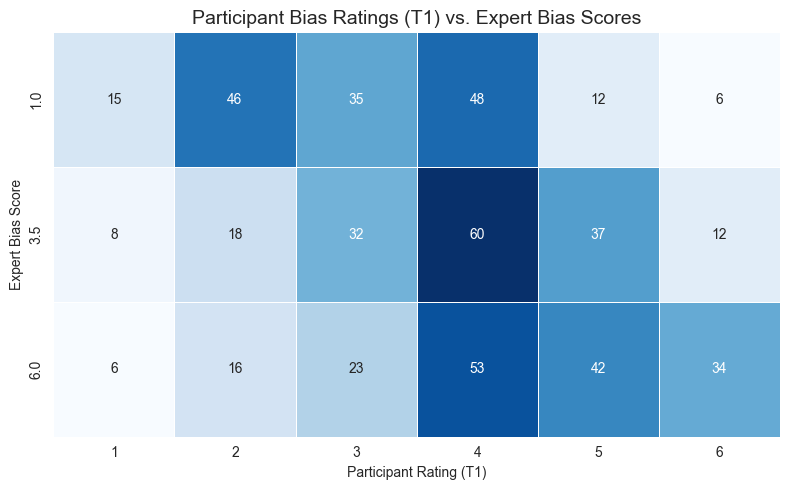

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the necessary columns exist and drop missing values
heatmap_data = df_relevant[['ExpertBiasScore', 'BiasT1Numeric']].dropna()

# Create a crosstab (count matrix)
heatmap_matrix = pd.crosstab(
    heatmap_data['ExpertBiasScore'],
    heatmap_data['BiasT1Numeric']
).sort_index()

# Create heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5)

plt.title("Participant Bias Ratings (T1) vs. Expert Bias Scores", fontsize=14)
plt.xlabel("Participant Rating (T1)")
plt.ylabel("Expert Bias Score")
plt.tight_layout()
plt.show()


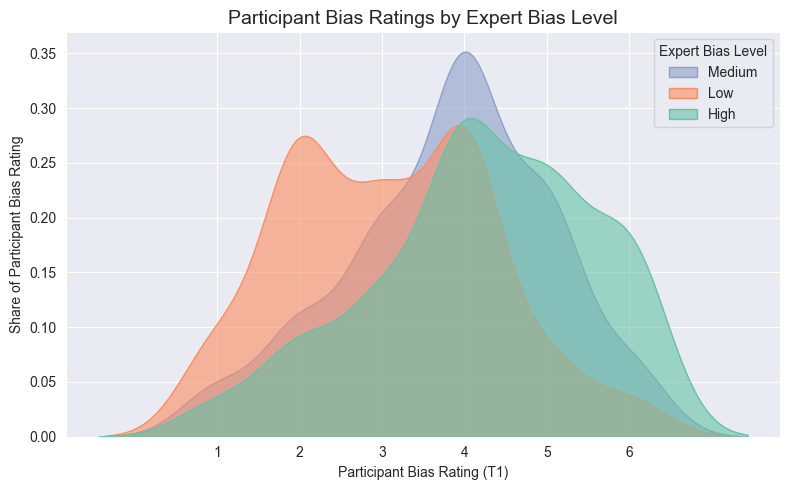

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values
plot_data = df_relevant[['article_bias_level', 'BiasT1Numeric']].dropna()

# Plot KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df_relevant,
    x="BiasT1Numeric",
    hue="article_bias_level",
    fill=True,
    common_norm=False,
    palette="Set2",
    alpha=0.6
)

# Labels and title
plt.title("Participant Bias Ratings by Expert Bias Level", fontsize=14)
plt.xlabel("Participant Bias Rating (T1)")
plt.ylabel("Share of Participant Bias Rating")
plt.xticks([1, 2, 3, 4, 5, 6])
plt.legend(title="Expert Bias Level", labels=["Medium", "Low", "High"])
plt.tight_layout()
plt.show()



DETAILED BIAS CHANGE ANALYSIS

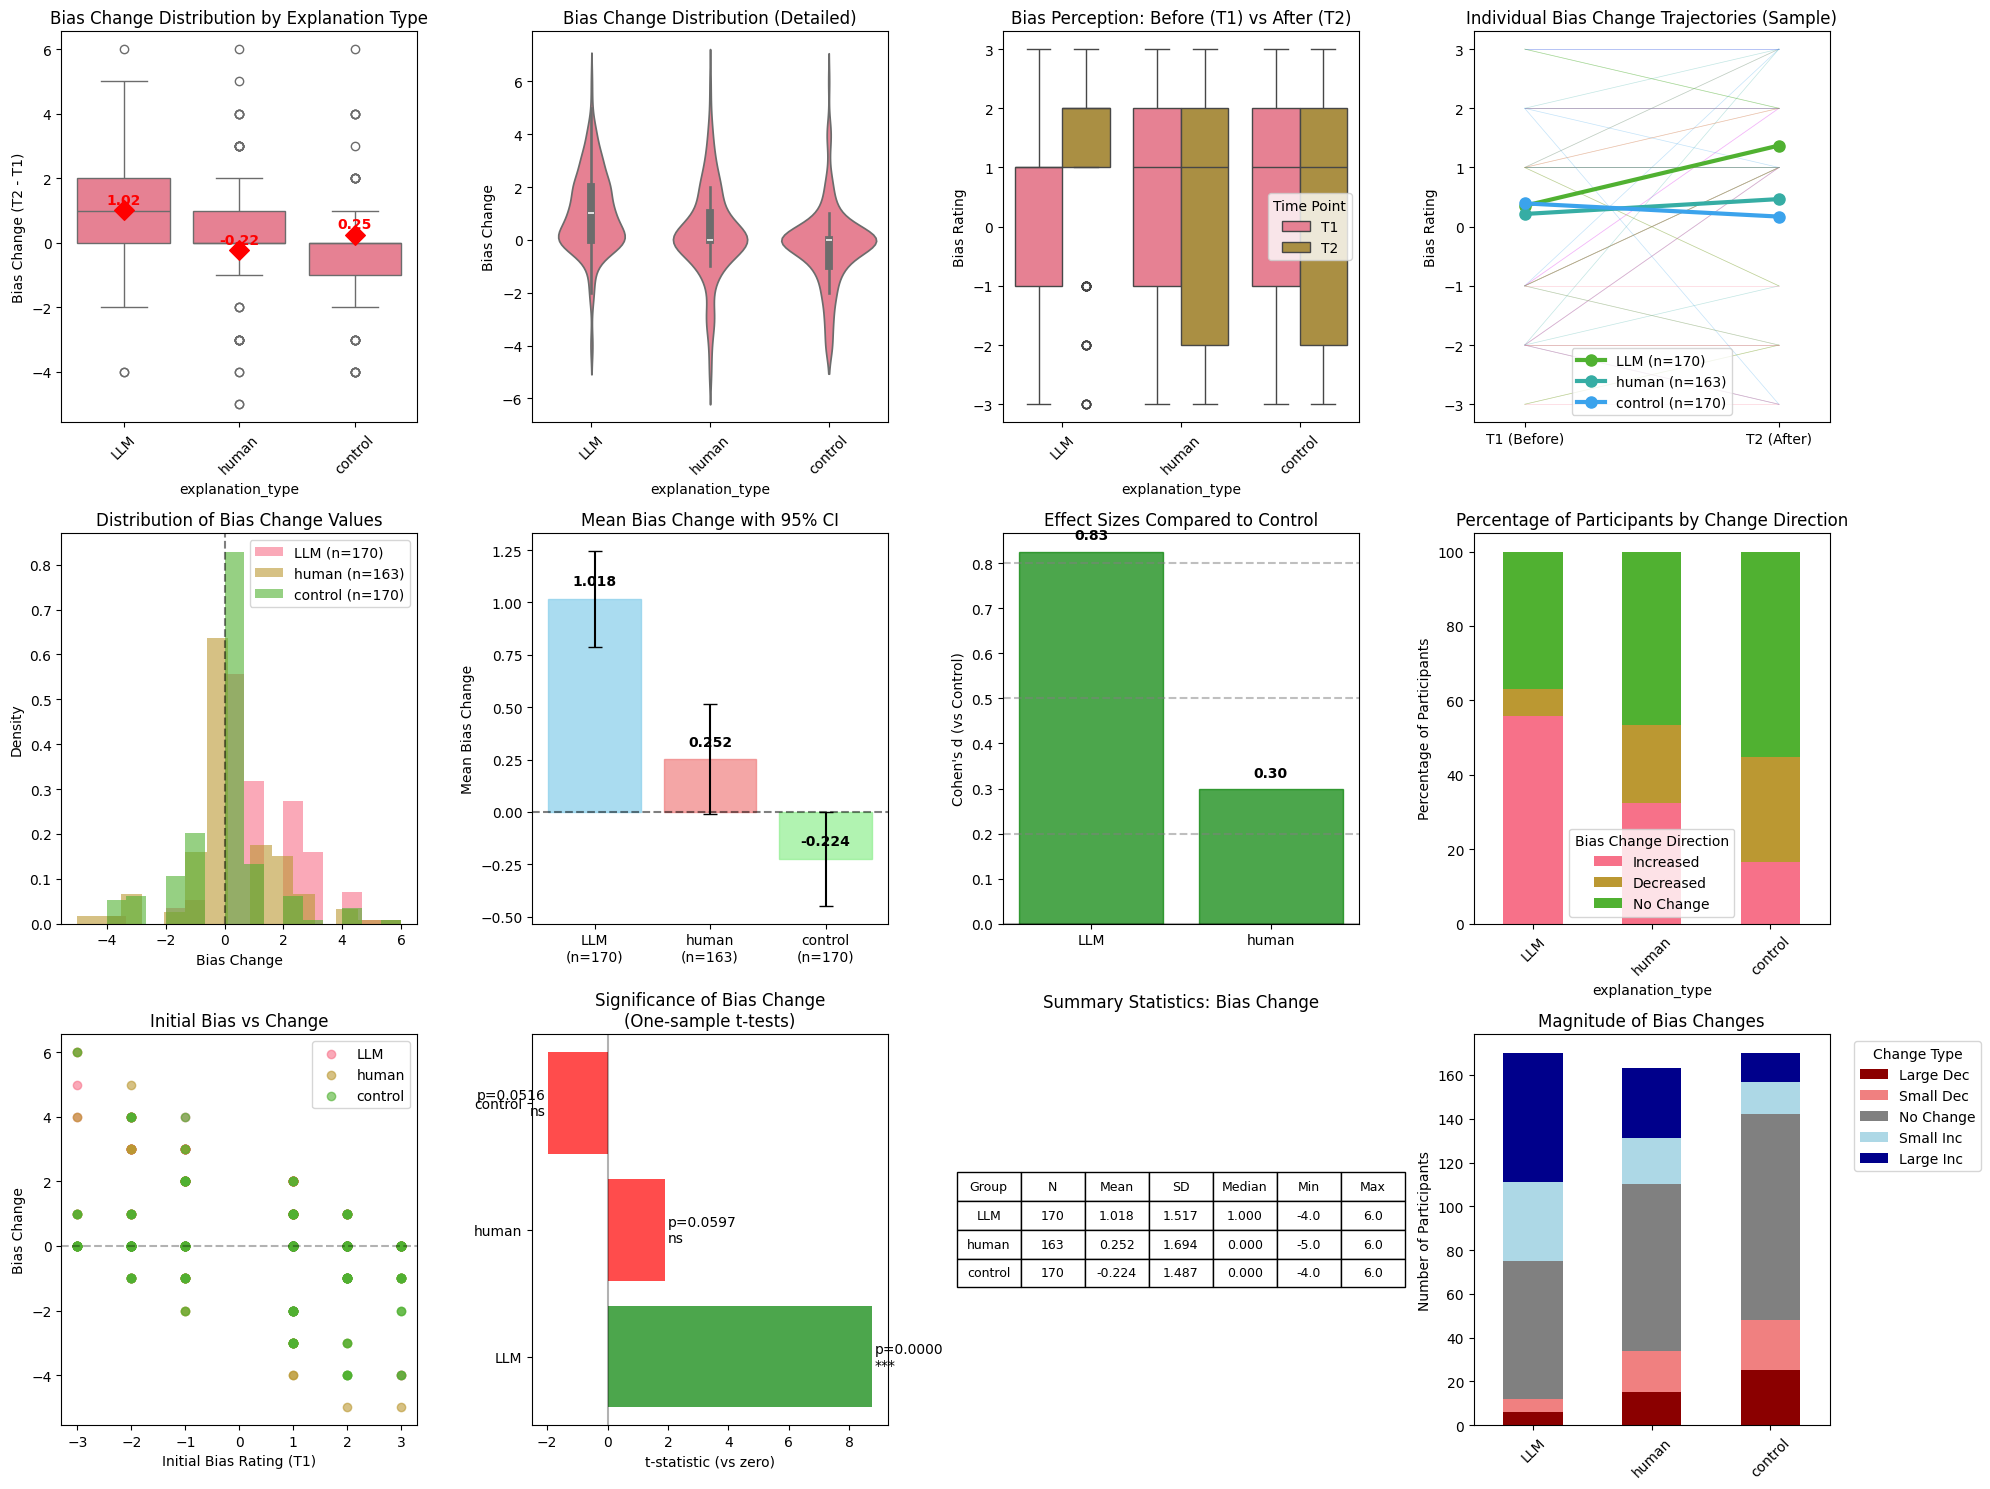

DETAILED BIAS CHANGE ANALYSIS SUMMARY

LLM GROUP (n=170):
  Mean bias change: 1.018
  Standard deviation: 1.517
  Median: 1.000
  Range: -4.0 to 6.0
  % with increased bias: 55.9%
  % with decreased bias: 7.1%
  % with no change: 37.1%
  Significance test vs 0: t = 8.746, p = 0.000000

HUMAN GROUP (n=163):
  Mean bias change: 0.252
  Standard deviation: 1.694
  Median: 0.000
  Range: -5.0 to 6.0
  % with increased bias: 32.5%
  % with decreased bias: 20.9%
  % with no change: 46.6%
  Significance test vs 0: t = 1.896, p = 0.059724

CONTROL GROUP (n=170):
  Mean bias change: -0.224
  Standard deviation: 1.487
  Median: 0.000
  Range: -4.0 to 6.0
  % with increased bias: 16.5%
  % with decreased bias: 28.2%
  % with no change: 55.3%
  Significance test vs 0: t = -1.960, p = 0.051588



In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")
fig = plt.figure(figsize=(20, 15))

# ============================================================================
# 1. BASIC DISTRIBUTION OF BIAS CHANGE BY EXPLANATION TYPE
# ============================================================================
plt.subplot(3, 4, 1)
sns.boxplot(data=df_relevant, x='explanation_type', y='BiasChange')
plt.title('Bias Change Distribution by Explanation Type')
plt.ylabel('Bias Change (T2 - T1)')
plt.xticks(rotation=45)

# Add means as points
means = df_relevant.groupby('explanation_type')['BiasChange'].mean()
for i, (exp_type, mean_val) in enumerate(means.items()):
    plt.scatter(i, mean_val, color='red', s=100, marker='D', zorder=10)
    plt.text(i, mean_val + 0.1, f'{mean_val:.2f}', ha='center', va='bottom',
             fontweight='bold', color='red')

# ============================================================================
# 2. VIOLIN PLOT FOR BETTER DISTRIBUTION UNDERSTANDING
# ============================================================================
plt.subplot(3, 4, 2)
sns.violinplot(data=df_relevant, x='explanation_type', y='BiasChange')
plt.title('Bias Change Distribution (Detailed)')
plt.ylabel('Bias Change')
plt.xticks(rotation=45)

# ============================================================================
# 3. BEFORE/AFTER COMPARISON - BIAS T1 vs T2
# ============================================================================
plt.subplot(3, 4, 3)
# Reshape data for before/after comparison
bias_comparison = []
for _, row in df_relevant.iterrows():
    bias_comparison.extend([
        {'explanation_type': row['explanation_type'], 'time': 'T1', 'bias': row['bias_t1_num']},
        {'explanation_type': row['explanation_type'], 'time': 'T2', 'bias': row['bias_t2_num']}
    ])
bias_df = pd.DataFrame(bias_comparison)

sns.boxplot(data=bias_df, x='explanation_type', y='bias', hue='time')
plt.title('Bias Perception: Before (T1) vs After (T2)')
plt.ylabel('Bias Rating')
plt.xticks(rotation=45)
plt.legend(title='Time Point')

# ============================================================================
# 4. INDIVIDUAL TRAJECTORIES (SAMPLE)
# ============================================================================
plt.subplot(3, 4, 4)
# Sample some participants to show individual changes
sample_size = min(50, len(df_relevant))
sample_df = df_relevant.sample(n=sample_size, random_state=42)

for exp_type in df_relevant['explanation_type'].unique():
    subset = sample_df[sample_df['explanation_type'] == exp_type]
    for _, row in subset.iterrows():
        plt.plot([1, 2], [row['bias_t1_num'], row['bias_t2_num']],
                 alpha=0.3, linewidth=0.5)

# Add mean trajectories
for i, exp_type in enumerate(df_relevant['explanation_type'].unique()):
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]
    mean_t1 = subset['bias_t1_num'].mean()
    mean_t2 = subset['bias_t2_num'].mean()
    plt.plot([1, 2], [mean_t1, mean_t2], linewidth=3,
             label=f'{exp_type} (n={len(subset)})', marker='o', markersize=8)

plt.xlim(0.8, 2.2)
plt.xticks([1, 2], ['T1 (Before)', 'T2 (After)'])
plt.ylabel('Bias Rating')
plt.title('Individual Bias Change Trajectories (Sample)')
plt.legend()

# ============================================================================
# 5. DISTRIBUTION OF BIAS CHANGE VALUES
# ============================================================================
plt.subplot(3, 4, 5)
for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]
    plt.hist(subset['BiasChange'], alpha=0.6, label=f'{exp_type} (n={len(subset)})',
             bins=15, density=True)

plt.xlabel('Bias Change')
plt.ylabel('Density')
plt.title('Distribution of Bias Change Values')
plt.legend()
plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='No Change')

# ============================================================================
# 6. MEAN BIAS CHANGE WITH CONFIDENCE INTERVALS
# ============================================================================
plt.subplot(3, 4, 6)
means = []
ci_lower = []
ci_upper = []
labels = []

for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange']
    mean_val = subset.mean()
    ci = stats.t.interval(0.95, len(subset)-1, loc=mean_val, scale=stats.sem(subset))

    means.append(mean_val)
    ci_lower.append(ci[0])
    ci_upper.append(ci[1])
    labels.append(f'{exp_type}\n(n={len(subset)})')

x_pos = range(len(means))
bars = plt.bar(x_pos, means, yerr=[np.array(means) - np.array(ci_lower),
                                   np.array(ci_upper) - np.array(means)],
               capsize=5, alpha=0.7)

# Color bars and add value labels
colors = ['skyblue', 'lightcoral', 'lightgreen']
for bar, color, mean_val in zip(bars, colors[:len(bars)], means):
    bar.set_color(color)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(x_pos, labels)
plt.ylabel('Mean Bias Change')
plt.title('Mean Bias Change with 95% CI')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# ============================================================================
# 7. EFFECT SIZES (COHEN'S D FROM BASELINE)
# ============================================================================
plt.subplot(3, 4, 7)
if 'control' in df_relevant['explanation_type'].unique():
    control_data = df_relevant[df_relevant['explanation_type'] == 'control']['BiasChange']
    control_mean = control_data.mean()
    control_std = control_data.std()

    effect_sizes = []
    effect_labels = []

    for exp_type in df_relevant['explanation_type'].unique():
        if exp_type != 'control':
            exp_data = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange']
            # Cohen's d comparing to control
            pooled_std = np.sqrt(((len(exp_data) - 1) * exp_data.std()**2 +
                                  (len(control_data) - 1) * control_std**2) /
                                 (len(exp_data) + len(control_data) - 2))
            cohens_d = (exp_data.mean() - control_mean) / pooled_std
            effect_sizes.append(cohens_d)
            effect_labels.append(f'{exp_type}')

    bars = plt.bar(range(len(effect_sizes)), effect_sizes, alpha=0.7)
    for bar, effect in zip(bars, effect_sizes):
        color = 'green' if effect > 0 else 'red'
        bar.set_color(color)
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 if effect > 0 else bar.get_height() - 0.05,
                 f'{effect:.2f}', ha='center', va='bottom' if effect > 0 else 'top', fontweight='bold')

    plt.xticks(range(len(effect_labels)), effect_labels)
    plt.ylabel("Cohen's d (vs Control)")
    plt.title("Effect Sizes Compared to Control")
    plt.axhline(0, color='black', linestyle='-', alpha=0.3)
    plt.axhline(0.2, color='gray', linestyle='--', alpha=0.5, label='Small effect')
    plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Medium effect')
    plt.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Large effect')

# ============================================================================
# 8. PERCENTAGE OF PARTICIPANTS WITH POSITIVE/NEGATIVE CHANGE
# ============================================================================
plt.subplot(3, 4, 8)
change_summary = []
for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]
    increased = (subset['BiasChange'] > 0).sum()
    decreased = (subset['BiasChange'] < 0).sum()
    no_change = (subset['BiasChange'] == 0).sum()
    total = len(subset)

    change_summary.append({
        'explanation_type': exp_type,
        'Increased': increased/total * 100,
        'Decreased': decreased/total * 100,
        'No Change': no_change/total * 100
    })

change_df = pd.DataFrame(change_summary)
change_df.set_index('explanation_type').plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Percentage of Participants by Change Direction')
plt.ylabel('Percentage of Participants')
plt.xticks(rotation=45)
plt.legend(title='Bias Change Direction')

# ============================================================================
# 9. CORRELATION BETWEEN T1 AND BIAS CHANGE
# ============================================================================
plt.subplot(3, 4, 9)
for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]
    plt.scatter(subset['bias_t1_num'], subset['BiasChange'], alpha=0.6, label=exp_type)

plt.xlabel('Initial Bias Rating (T1)')
plt.ylabel('Bias Change')
plt.title('Initial Bias vs Change')
plt.legend()
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# ============================================================================
# 10. STATISTICAL SIGNIFICANCE INDICATORS
# ============================================================================
plt.subplot(3, 4, 10)
# One-sample t-tests against zero for each group
p_values = []
t_stats = []
group_names = []

for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange']
    t_stat, p_val = stats.ttest_1samp(subset, 0)
    p_values.append(p_val)
    t_stats.append(t_stat)
    group_names.append(exp_type)

# Create significance plot
y_pos = range(len(group_names))
colors = ['green' if p < 0.05 else 'red' for p in p_values]
bars = plt.barh(y_pos, t_stats, color=colors, alpha=0.7)

for i, (bar, p_val) in enumerate(zip(bars, p_values)):
    sig_text = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    plt.text(bar.get_width() + 0.1 if bar.get_width() > 0 else bar.get_width() - 0.1,
             bar.get_y() + bar.get_height()/2,
             f'p={p_val:.4f}\n{sig_text}',
             ha='left' if bar.get_width() > 0 else 'right', va='center')

plt.yticks(y_pos, group_names)
plt.xlabel('t-statistic (vs zero)')
plt.title('Significance of Bias Change\n(One-sample t-tests)')
plt.axvline(0, color='black', linestyle='-', alpha=0.3)

# ============================================================================
# 11. SUMMARY STATISTICS TABLE
# ============================================================================
plt.subplot(3, 4, 11)
plt.axis('off')

# Create summary statistics
summary_stats = []
for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange']
    stats_dict = {
        'Group': exp_type,
        'N': len(subset),
        'Mean': f"{subset.mean():.3f}",
        'SD': f"{subset.std():.3f}",
        'Median': f"{subset.median():.3f}",
        'Min': f"{subset.min():.1f}",
        'Max': f"{subset.max():.1f}"
    }
    summary_stats.append(stats_dict)

summary_df = pd.DataFrame(summary_stats)
table = plt.table(cellText=summary_df.values,
                  colLabels=summary_df.columns,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.15]*len(summary_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
plt.title('Summary Statistics: Bias Change', pad=20)

# ============================================================================
# 12. DIRECTIONAL ANALYSIS
# ============================================================================
plt.subplot(3, 4, 12)
# Show what kind of changes are happening
direction_data = []
for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]

    # Count changes by magnitude
    large_increase = (subset['BiasChange'] >= 2).sum()
    small_increase = ((subset['BiasChange'] > 0) & (subset['BiasChange'] < 2)).sum()
    no_change = (subset['BiasChange'] == 0).sum()
    small_decrease = ((subset['BiasChange'] < 0) & (subset['BiasChange'] > -2)).sum()
    large_decrease = (subset['BiasChange'] <= -2).sum()

    direction_data.append([large_decrease, small_decrease, no_change, small_increase, large_increase])

direction_df = pd.DataFrame(direction_data,
                            columns=['Large Dec', 'Small Dec', 'No Change', 'Small Inc', 'Large Inc'],
                            index=df_relevant['explanation_type'].unique())

direction_df.plot(kind='bar', stacked=True, ax=plt.gca(),
                  color=['darkred', 'lightcoral', 'gray', 'lightblue', 'darkblue'])
plt.title('Magnitude of Bias Changes')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45)
plt.legend(title='Change Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ============================================================================
# PRINT DETAILED SUMMARY
# ============================================================================
print("="*80)
print("DETAILED BIAS CHANGE ANALYSIS SUMMARY")
print("="*80)

for exp_type in df_relevant['explanation_type'].unique():
    subset = df_relevant[df_relevant['explanation_type'] == exp_type]['BiasChange']
    t_stat, p_val = stats.ttest_1samp(subset, 0)

    print(f"\n{exp_type.upper()} GROUP (n={len(subset)}):")
    print(f"  Mean bias change: {subset.mean():.3f}")
    print(f"  Standard deviation: {subset.std():.3f}")
    print(f"  Median: {subset.median():.3f}")
    print(f"  Range: {subset.min():.1f} to {subset.max():.1f}")
    print(f"  % with increased bias: {(subset > 0).mean()*100:.1f}%")
    print(f"  % with decreased bias: {(subset < 0).mean()*100:.1f}%")
    print(f"  % with no change: {(subset == 0).mean()*100:.1f}%")
    print(f"  Significance test vs 0: t = {t_stat:.3f}, p = {p_val:.6f}")

print("\n" + "="*80)

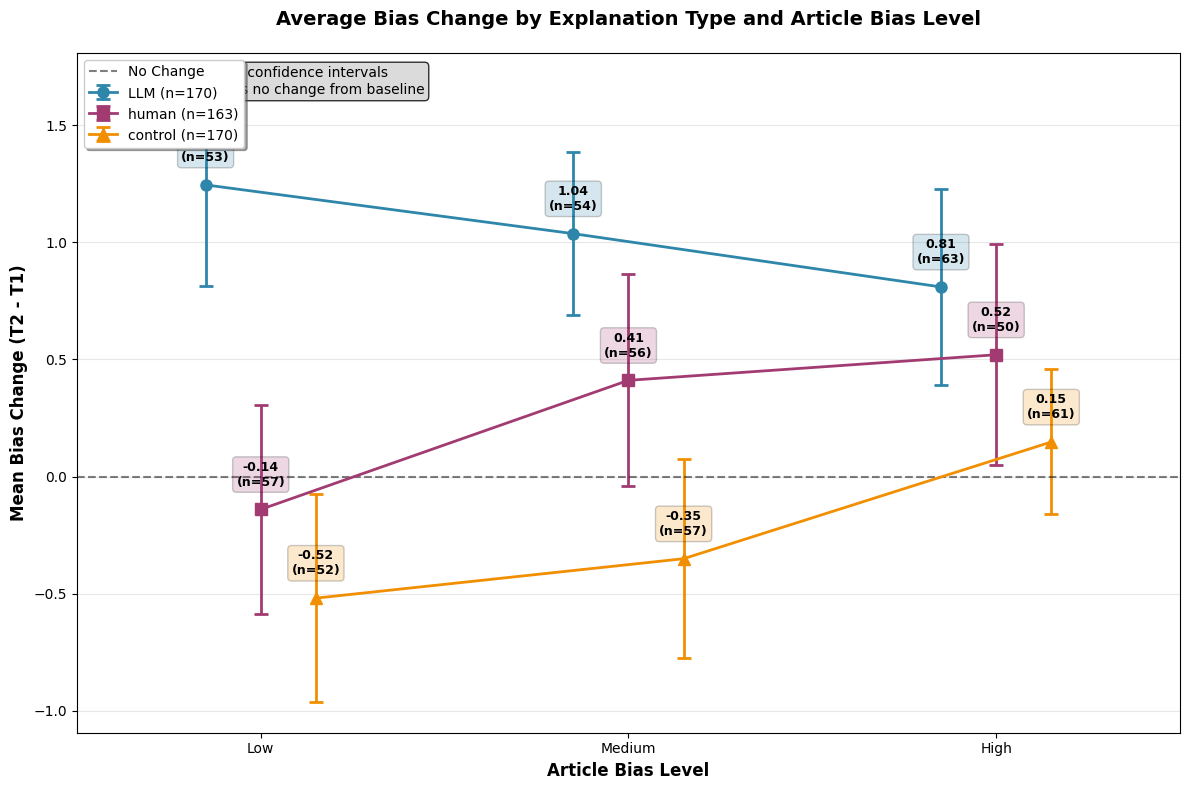

BIAS CHANGE BY EXPLANATION TYPE AND ARTICLE BIAS LEVEL
Explanation  Bias Level N    Mean     95% CI               Interpretation
--------------------------------------------------------------------------------
LLM          high       63   0.810    [0.39, 1.23]         Significant increase
LLM          low        53   1.245    [0.81, 1.68]         Significant increase
LLM          medium     54   1.037    [0.69, 1.38]         Significant increase
human        high       50   0.520    [0.05, 0.99]         Significant increase
human        low        57   -0.140   [-0.59, 0.31]        No significant change
human        medium     56   0.411    [-0.04, 0.86]        No significant change
control      high       61   0.148    [-0.16, 0.46]        No significant change
control      low        52   -0.519   [-0.96, -0.08]       Significant decrease
control      medium     57   -0.351   [-0.77, 0.07]        No significant change



In [21]:
summary_data = []
for exp_type in df_relevant['explanation_type'].unique():
    for bias_level in df_relevant['article_bias_level'].unique():
        subset = df_relevant[(df_relevant['explanation_type'] == exp_type) &
                             (df_relevant['article_bias_level'] == bias_level)]

        if len(subset) > 0:
            mean_change = subset['BiasChange'].mean()
            std_error = stats.sem(subset['BiasChange'])
            ci = stats.t.interval(0.95, len(subset)-1, loc=mean_change, scale=std_error)

            summary_data.append({
                'explanation_type': exp_type,
                'article_bias_level': bias_level,
                'mean_bias_change': mean_change,
                'std_error': std_error,
                'ci_lower': ci[0],
                'ci_upper': ci[1],
                'n': len(subset)
            })

summary_df = pd.DataFrame(summary_data)

# Create the plot
plt.figure(figsize=(12, 8))

# Define colors for each explanation type
colors = {'LLM': '#2E86AB', 'human': '#A23B72', 'control': '#F18F01'}
markers = {'LLM': 'o', 'human': 's', 'control': '^'}

# Plot each explanation type
for exp_type in summary_df['explanation_type'].unique():
    subset = summary_df[summary_df['explanation_type'] == exp_type]

    # Create x-axis positions (with slight offset for each explanation type)
    bias_levels = ['low', 'medium', 'high']
    x_positions = []
    for i, level in enumerate(bias_levels):
        if level in subset['article_bias_level'].values:
            if exp_type == 'LLM':
                x_positions.append(i - 0.15)
            elif exp_type == 'human':
                x_positions.append(i)
            else:  # control
                x_positions.append(i + 0.15)

    # Get corresponding y values and errors
    y_values = []
    errors = []
    n_values = []

    for level in bias_levels:
        level_data = subset[subset['article_bias_level'] == level]
        if len(level_data) > 0:
            y_values.append(level_data['mean_bias_change'].iloc[0])
            errors.append([level_data['mean_bias_change'].iloc[0] - level_data['ci_lower'].iloc[0],
                           level_data['ci_upper'].iloc[0] - level_data['mean_bias_change'].iloc[0]])
            n_values.append(level_data['n'].iloc[0])

    # Convert errors to proper format for errorbar
    if errors:
        errors = np.array(errors).T

    # Plot with error bars
    plt.errorbar(x_positions, y_values, yerr=errors,
                 label=f'{exp_type} (n={sum(n_values)})',
                 marker=markers.get(exp_type, 'o'),
                 color=colors.get(exp_type, 'gray'),
                 linewidth=2, markersize=8, capsize=5, capthick=2)

    # Add value labels on points
    for x, y, n in zip(x_positions, y_values, n_values):
        plt.annotate(f'{y:.2f}\n(n={n})',
                     xy=(x, y),
                     xytext=(0, 15),
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=9, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor=colors.get(exp_type, 'gray'), alpha=0.2))

# Customize the plot
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='No Change')
plt.xlabel('Article Bias Level', fontsize=12, fontweight='bold')
plt.ylabel('Mean Bias Change (T2 - T1)', fontsize=12, fontweight='bold')
plt.title('Average Bias Change by Explanation Type and Article Bias Level',
          fontsize=14, fontweight='bold', pad=20)

# Set x-axis
plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'])
plt.xlim(-0.5, 2.5)

# Add grid
plt.grid(True, alpha=0.3, axis='y')

# Customize legend
plt.legend(loc='upper left', frameon=True, shadow=True)

# Add overall statistics text box
stats_text = "Error bars show 95% confidence intervals\nDashed line indicates no change from baseline"
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
         fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed summary table
print("="*80)
print("BIAS CHANGE BY EXPLANATION TYPE AND ARTICLE BIAS LEVEL")
print("="*80)
print(f"{'Explanation':<12} {'Bias Level':<10} {'N':<4} {'Mean':<8} {'95% CI':<20} {'Interpretation'}")
print("-"*80)

for _, row in summary_df.iterrows():
    ci_text = f"[{row['ci_lower']:.2f}, {row['ci_upper']:.2f}]"

    # Determine interpretation
    if row['ci_lower'] > 0:
        interpretation = "Significant increase"
    elif row['ci_upper'] < 0:
        interpretation = "Significant decrease"
    else:
        interpretation = "No significant change"

    print(f"{row['explanation_type']:<12} {row['article_bias_level']:<10} {row['n']:<4} "
          f"{row['mean_bias_change']:<8.3f} {ci_text:<20} {interpretation}")

print("\n" + "="*80)

BIAS PERCEPTION CHANGE ANALYSIS
Total sample size: 503

1. OVERALL MOVEMENT COUNTS
------------------------------
Decreased bias perception     94
No change                    233
Increased bias perception    176
dtype: int64
Percentages:
Decreased bias perception    18.7
No change                    46.3
Increased bias perception    35.0
dtype: float64

2. MOVEMENT BY EXPERT BIAS LEVEL
----------------------------------------

Expert HIGH bias articles (n=174):
  Decreased bias perception: 20 (11.5%)
  No change:                 90 (51.7%)
  Increased bias perception: 64 (36.8%)

Expert MEDIUM bias articles (n=167):
  Decreased bias perception: 33 (19.8%)
  No change:                 74 (44.3%)
  Increased bias perception: 60 (35.9%)

Expert LOW bias articles (n=162):
  Decreased bias perception: 41 (25.3%)
  No change:                 69 (42.6%)
  Increased bias perception: 52 (32.1%)

3. MOVEMENT BY EXPLANATION TYPE
-----------------------------------

CONTROL explanations (n=170):


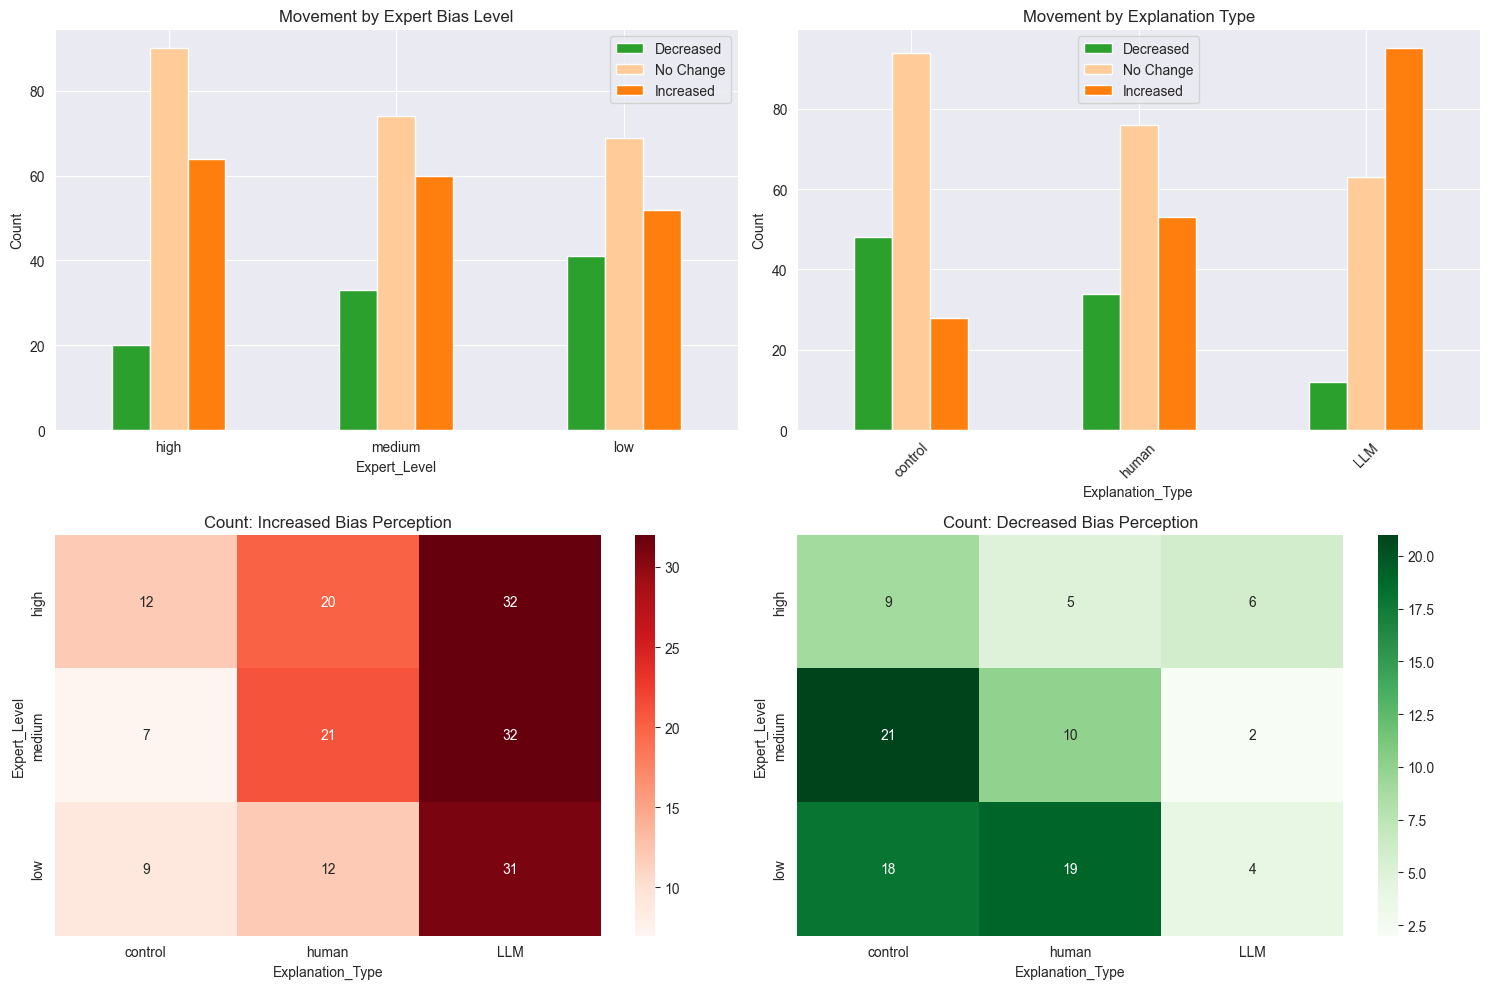


2. EXPERT ALIGNMENT ANALYSIS
----------------------------------------
Alignment with Expert Opinion (Before → After Treatment):
-------------------------------------------------------

CONTROL Explanation:
  high bias (n=61):
    Before: 10/61 aligned (16.4%)
    After:  12/61 aligned (19.7%)
    Change: Became aligned=5, Became unaligned=3
  medium bias (n=57):
    Before: 30/57 aligned (52.6%)
    After:  26/57 aligned (45.6%)
    Change: Became aligned=6, Became unaligned=10
  low bias (n=52):
    Before: 28/52 aligned (53.8%)
    After:  35/52 aligned (67.3%)
    Change: Became aligned=11, Became unaligned=4

HUMAN Explanation:
  high bias (n=50):
    Before: 9/50 aligned (18.0%)
    After:  16/50 aligned (32.0%)
    Change: Became aligned=8, Became unaligned=1
  medium bias (n=56):
    Before: 31/56 aligned (55.4%)
    After:  42/56 aligned (75.0%)
    Change: Became aligned=17, Became unaligned=6
  low bias (n=57):
    Before: 35/57 aligned (61.4%)
    After:  35/57 aligned (61.

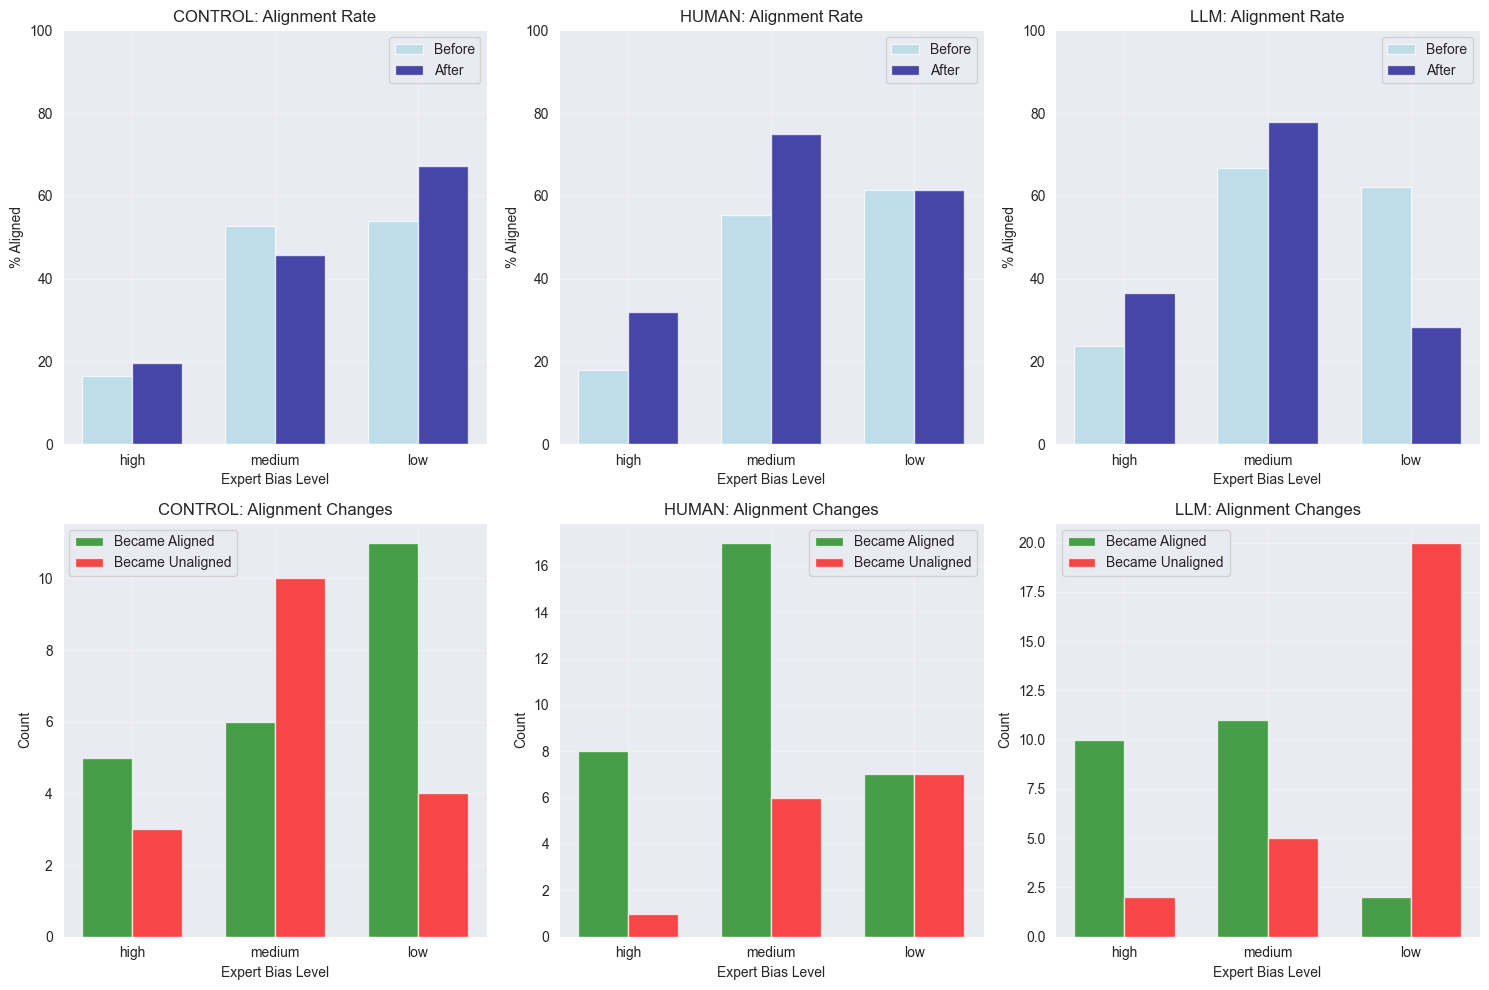

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_bias_perception_change(df):
    """
    Simple analysis of bias perception changes by expert level and explanation type
    Focus on quantities: how many increased/decreased/stayed same
    """

    # Data preparation
    df_clean = df.dropna(subset=['BiasChange', 'article_bias_level', 'explanation_type'])

    # Define order for consistent display
    bias_level_order = ['high', 'medium', 'low']
    explanation_order = ['control', 'human', 'LLM']

    print("="*60)
    print("BIAS PERCEPTION CHANGE ANALYSIS")
    print("="*60)

    print(f"Total sample size: {len(df_clean)}")

    # 1. Overall movement counts
    print("\n1. OVERALL MOVEMENT COUNTS")
    print("-" * 30)

    overall_movement = pd.Series({
        'Decreased bias perception': (df_clean['BiasChange'] < 0).sum(),
        'No change': (df_clean['BiasChange'] == 0).sum(),
        'Increased bias perception': (df_clean['BiasChange'] > 0).sum()
    })

    print(overall_movement)
    print(f"Percentages:")
    print((overall_movement / len(df_clean) * 100).round(1))

    # 2. Movement by Expert Bias Level (ordered: high, medium, low)
    print("\n2. MOVEMENT BY EXPERT BIAS LEVEL")
    print("-" * 40)

    for bias_level in bias_level_order:
        if bias_level in df_clean['article_bias_level'].values:
            subset = df_clean[df_clean['article_bias_level'] == bias_level]

            print(f"\nExpert {bias_level.upper()} bias articles (n={len(subset)}):")
            decreased = (subset['BiasChange'] < 0).sum()
            no_change = (subset['BiasChange'] == 0).sum()
            increased = (subset['BiasChange'] > 0).sum()

            print(f"  Decreased bias perception: {decreased} ({decreased/len(subset)*100:.1f}%)")
            print(f"  No change:                 {no_change} ({no_change/len(subset)*100:.1f}%)")
            print(f"  Increased bias perception: {increased} ({increased/len(subset)*100:.1f}%)")

    # 3. Movement by Explanation Type
    print("\n3. MOVEMENT BY EXPLANATION TYPE")
    print("-" * 35)

    for exp_type in explanation_order:
        if exp_type in df_clean['explanation_type'].values:
            subset = df_clean[df_clean['explanation_type'] == exp_type]

            print(f"\n{exp_type.upper()} explanations (n={len(subset)}):")
            decreased = (subset['BiasChange'] < 0).sum()
            no_change = (subset['BiasChange'] == 0).sum()
            increased = (subset['BiasChange'] > 0).sum()

            print(f"  Decreased bias perception: {decreased} ({decreased/len(subset)*100:.1f}%)")
            print(f"  No change:                 {no_change} ({no_change/len(subset)*100:.1f}%)")
            print(f"  Increased bias perception: {increased} ({increased/len(subset)*100:.1f}%)")

    # 4. Combined analysis: Expert Level × Explanation Type
    print("\n4. MOVEMENT BY EXPERT LEVEL AND EXPLANATION TYPE")
    print("-" * 55)

    # Create a summary table
    summary_data = []

    for bias_level in bias_level_order:
        for exp_type in explanation_order:
            subset = df_clean[(df_clean['article_bias_level'] == bias_level) &
                              (df_clean['explanation_type'] == exp_type)]

            if len(subset) > 0:
                decreased = (subset['BiasChange'] < 0).sum()
                no_change = (subset['BiasChange'] == 0).sum()
                increased = (subset['BiasChange'] > 0).sum()

                summary_data.append({
                    'Expert_Level': bias_level,
                    'Explanation_Type': exp_type,
                    'Sample_Size': len(subset),
                    'Decreased': decreased,
                    'No_Change': no_change,
                    'Increased': increased,
                    'Decreased_Pct': round(decreased/len(subset)*100, 1),
                    'No_Change_Pct': round(no_change/len(subset)*100, 1),
                    'Increased_Pct': round(increased/len(subset)*100, 1)
                })

    summary_df = pd.DataFrame(summary_data)

    # Display the summary table
    for bias_level in bias_level_order:
        if bias_level in summary_df['Expert_Level'].values:
            print(f"\nExpert {bias_level.upper()} bias articles:")
            level_data = summary_df[summary_df['Expert_Level'] == bias_level]

            for _, row in level_data.iterrows():
                print(f"  {row['Explanation_Type']} (n={row['Sample_Size']}):")
                print(f"    Decreased: {row['Decreased']} ({row['Decreased_Pct']}%)")
                print(f"    No change: {row['No_Change']} ({row['No_Change_Pct']}%)")
                print(f"    Increased: {row['Increased']} ({row['Increased_Pct']}%)")

    # 5. Simple visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # 15x10 makes it more readable

    # Plot 1: Movement by Expert Level
    ax1 = axes[0, 0]
    expert_summary = []
    for bias_level in bias_level_order:
        if bias_level in df_clean['article_bias_level'].values:
            subset = df_clean[df_clean['article_bias_level'] == bias_level]
            expert_summary.append({
                'Expert_Level': bias_level,
                'Decreased': (subset['BiasChange'] < 0).sum(),
                'No_Change': (subset['BiasChange'] == 0).sum(),
                'Increased': (subset['BiasChange'] > 0).sum()
            })

    expert_df = pd.DataFrame(expert_summary)
    expert_df.set_index('Expert_Level')[['Decreased', 'No_Change', 'Increased']].plot(
        kind='bar', ax=ax1, color=['#2ca02c', '#ffcc99', '#ff7f0e'])
    ax1.set_title('Movement by Expert Bias Level')
    ax1.set_ylabel('Count')
    ax1.legend(['Decreased', 'No Change', 'Increased'])
    ax1.tick_params(axis='x', rotation=0)

    # Plot 2: Movement by Explanation Type
    ax2 = axes[0, 1]
    exp_summary = []
    for exp_type in explanation_order:
        if exp_type in df_clean['explanation_type'].values:
            subset = df_clean[df_clean['explanation_type'] == exp_type]
            exp_summary.append({
                'Explanation_Type': exp_type,
                'Decreased': (subset['BiasChange'] < 0).sum(),
                'No_Change': (subset['BiasChange'] == 0).sum(),
                'Increased': (subset['BiasChange'] > 0).sum()
            })

    exp_df = pd.DataFrame(exp_summary)
    exp_df.set_index('Explanation_Type')[['Decreased', 'No_Change', 'Increased']].plot(
        kind='bar', ax=ax2, color=['#2ca02c', '#ffcc99', '#ff7f0e'])
    ax2.set_title('Movement by Explanation Type')
    ax2.set_ylabel('Count')
    ax2.legend(['Decreased', 'No Change', 'Increased'])
    ax2.tick_params(axis='x', rotation=45)

    # Plot 3: Heatmap of "Increased" counts
    ax3 = axes[1, 0]
    pivot_increased = summary_df.pivot(index='Expert_Level', columns='Explanation_Type', values='Increased')
    pivot_increased = pivot_increased.reindex(bias_level_order)
    pivot_increased = pivot_increased.reindex(columns=explanation_order)
    sns.heatmap(pivot_increased, annot=True, fmt='d', cmap='Reds', ax=ax3)
    ax3.set_title('Count: Increased Bias Perception')

    # Plot 4: Heatmap of "Decreased" counts
    ax4 = axes[1, 1]
    pivot_decreased = summary_df.pivot(index='Expert_Level', columns='Explanation_Type', values='Decreased')
    pivot_decreased = pivot_decreased.reindex(bias_level_order)
    pivot_decreased = pivot_decreased.reindex(columns=explanation_order)
    sns.heatmap(pivot_decreased, annot=True, fmt='d', cmap='Greens', ax=ax4)
    ax4.set_title('Count: Decreased Bias Perception')

    plt.tight_layout()
    plt.show()

    return summary_df

def analyze_expert_alignment(df):
    """
    Analyze alignment with expert opinion using specific bias level mappings
    """

    print("\n2. EXPERT ALIGNMENT ANALYSIS")
    print("-" * 40)

    # Data preparation
    df_clean = df.dropna(subset=['bias_t1', 'bias_t2', 'article_bias_level', 'explanation_type'])

    # Define alignment criteria
    def get_alignment_status(bias_response, expert_level):
        """Check if bias response aligns with expert level"""
        if expert_level == 'low':
            return bias_response in ['Strongly disagree', 'Disagree', 'Somewhat disagree']
        elif expert_level == 'medium':
            return bias_response in ['Somewhat agree', 'Agree']
        elif expert_level == 'high':
            return bias_response in ['Strongly agree']
        return False

    # Calculate alignment before and after treatment
    df_clean['aligned_t1'] = df_clean.apply(
        lambda row: get_alignment_status(row['bias_t1'], row['article_bias_level']), axis=1
    )
    df_clean['aligned_t2'] = df_clean.apply(
        lambda row: get_alignment_status(row['bias_t2'], row['article_bias_level']), axis=1
    )

    # Order categories
    bias_order = ['high', 'medium', 'low']
    exp_order = ['control', 'human', 'LLM']

    print("Alignment with Expert Opinion (Before → After Treatment):")
    print("-" * 55)

    alignment_results = []

    for exp_type in exp_order:
        if exp_type in df_clean['explanation_type'].values:
            exp_data = df_clean[df_clean['explanation_type'] == exp_type]

            print(f"\n{exp_type.upper()} Explanation:")

            for bias_level in bias_order:
                if bias_level in exp_data['article_bias_level'].values:
                    group_data = exp_data[exp_data['article_bias_level'] == bias_level]

                    aligned_before = group_data['aligned_t1'].sum()
                    aligned_after = group_data['aligned_t2'].sum()
                    total = len(group_data)

                    # Calculate alignment change
                    became_aligned = ((~group_data['aligned_t1']) & group_data['aligned_t2']).sum()
                    became_unaligned = (group_data['aligned_t1'] & (~group_data['aligned_t2'])).sum()
                    stayed_aligned = (group_data['aligned_t1'] & group_data['aligned_t2']).sum()
                    stayed_unaligned = ((~group_data['aligned_t1']) & (~group_data['aligned_t2'])).sum()

                    print(f"  {bias_level} bias (n={total}):")
                    print(f"    Before: {aligned_before}/{total} aligned ({aligned_before/total*100:.1f}%)")
                    print(f"    After:  {aligned_after}/{total} aligned ({aligned_after/total*100:.1f}%)")
                    print(f"    Change: Became aligned={became_aligned}, Became unaligned={became_unaligned}")

                    alignment_results.append({
                        'explanation_type': exp_type,
                        'expert_bias_level': bias_level,
                        'aligned_before': aligned_before,
                        'aligned_after': aligned_after,
                        'became_aligned': became_aligned,
                        'became_unaligned': became_unaligned,
                        'stayed_aligned': stayed_aligned,
                        'stayed_unaligned': stayed_unaligned,
                        'total': total
                    })

    # Create alignment visualization
    alignment_df = pd.DataFrame(alignment_results)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Before/After alignment rates
    for i, exp_type in enumerate(exp_order):
        if exp_type in alignment_df['explanation_type'].values:
            exp_data = alignment_df[alignment_df['explanation_type'] == exp_type]
            exp_data = exp_data.set_index('expert_bias_level').reindex(bias_order).reset_index()

            before_pct = (exp_data['aligned_before'] / exp_data['total'] * 100)
            after_pct = (exp_data['aligned_after'] / exp_data['total'] * 100)

            x = range(len(exp_data))
            width = 0.35

            axes[0, i].bar([j - width/2 for j in x], before_pct, width,
                           label='Before', color='lightblue', alpha=0.7)
            axes[0, i].bar([j + width/2 for j in x], after_pct, width,
                           label='After', color='darkblue', alpha=0.7)

            axes[0, i].set_title(f'{exp_type.upper()}: Alignment Rate')
            axes[0, i].set_xlabel('Expert Bias Level')
            axes[0, i].set_ylabel('% Aligned')
            axes[0, i].set_xticks(x)
            axes[0, i].set_xticklabels(exp_data['expert_bias_level'])
            axes[0, i].legend()
            axes[0, i].set_ylim(0, 100)
            axes[0, i].grid(True, alpha=0.3)

    # Alignment changes
    for i, exp_type in enumerate(exp_order):
        if exp_type in alignment_df['explanation_type'].values:
            exp_data = alignment_df[alignment_df['explanation_type'] == exp_type]
            exp_data = exp_data.set_index('expert_bias_level').reindex(bias_order).reset_index()

            x = range(len(exp_data))
            width = 0.35

            axes[1, i].bar([j - width/2 for j in x], exp_data['became_aligned'], width,
                           label='Became Aligned', color='green', alpha=0.7)
            axes[1, i].bar([j + width/2 for j in x], exp_data['became_unaligned'], width,
                           label='Became Unaligned', color='red', alpha=0.7)

            axes[1, i].set_title(f'{exp_type.upper()}: Alignment Changes')
            axes[1, i].set_xlabel('Expert Bias Level')
            axes[1, i].set_ylabel('Count')
            axes[1, i].set_xticks(x)
            axes[1, i].set_xticklabels(exp_data['expert_bias_level'])
            axes[1, i].legend()
            axes[1, i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return alignment_df

# Example usage:
summary_df = analyze_bias_perception_change(df_relevant)
alignment_df = analyze_expert_alignment(df_relevant)